# 12 — Wave Stacking: Multi-Bullet Patterns in the Rumble

**Goal**: Scan the 50-bot rumble dataset for opponents that fire variable-power
bullet sequences, and identify near-simultaneous wave arrivals. This is a
quick empirical survey — deeper analysis deferred to a future notebook.

**Questions**:
1. Which bots fire variable power vs constant power?
2. Do any bots fire slow+fast pairs that converge at the target?
3. Do any bots fire 3-shot sequences (heavy+medium+light)?
4. At what distances do near-simultaneous arrivals occur?
5. How common are multi-wave-in-flight situations?

In [1]:
import sys; sys.path.insert(0, '.')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from _loader import build_robot_index, load_stratified

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Data

We load `waves.csv` (one row per detected opponent fire) and `ticks.csv`
(for fire power from the observer's perspective) across 50 bots × 8 battles.

In [2]:
selection = build_robot_index(max_robots=50, battles_per_robot=8, seed=42)
waves = load_stratified('waves.csv', selection)
print(f"Waves: {len(waves):,} rows")

Indexed 3888 ticks.csv files across 50 distinct robots from 1 root(s).
Selected 50 robots × ~8 battles = 400 (battle, robot) pairs to load.


d:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
d:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
d:\robocode-autopilot\intuition\.\_loader.py:170: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(frames, ignore_index=True)


Loaded 400 waves.csv files → 737,381 rows × 10 cols, 50 robots (~162.6 MB)
Waves: 737,381 rows


## 2. Fire Power Variability per Bot

For each opponent (the bot being observed), compute the standard deviation
of fire power. Bots with high std use variable power; bots with std ≈ 0 use
constant power. Variable power is a prerequisite for wave stacking.

In [3]:
# waves.csv records opponent fires from the observer's perspective.
# robot_name = observer, so the opponent is the one firing.
# Group by observer to get per-opponent fire-power stats.

power_stats = (
    waves.groupby('robot_name')['wave_bullet_power']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .sort_values('std', ascending=False)
    .reset_index()
)
power_stats.columns = ['observer', 'power_mean', 'power_std',
                        'power_min', 'power_max', 'fire_count']

# High std = variable power opponent
print("Top 20 opponents by fire-power variability (high std = variable power):")
print(power_stats.head(20).to_string(index=False))

Top 20 opponents by fire-power variability (high std = variable power):
               observer  power_mean  power_std  power_min  power_max  fire_count
          Roborio 1.2.4    1.017219   0.919006        0.1        3.0       23316
          DrussGT 3.1.7    1.161461   0.875280        0.1        3.0       18921
       Firestarter 2.0f    1.065586   0.857230        0.1        3.0       21822
           BeepBoop 2.0    0.809245   0.852265        0.1        3.0       28309
          Knight 0.6.28    0.925888   0.845292        0.1        3.0       24626
           Domogled 1.2    0.916081   0.842035        0.1        3.0       27056
          Foilist 1.3.1    1.223369   0.829735        0.1        3.0       15267
            Tomcat 3.68    0.874330   0.814102        0.1        3.0       21551
           Raven 3.56j8    1.300987   0.813236        0.1        3.0       15358
       Gilgalad 1.99.5c    1.146894   0.799599        0.1        3.0       17880
       Neuromancer 7.12    0.640176  

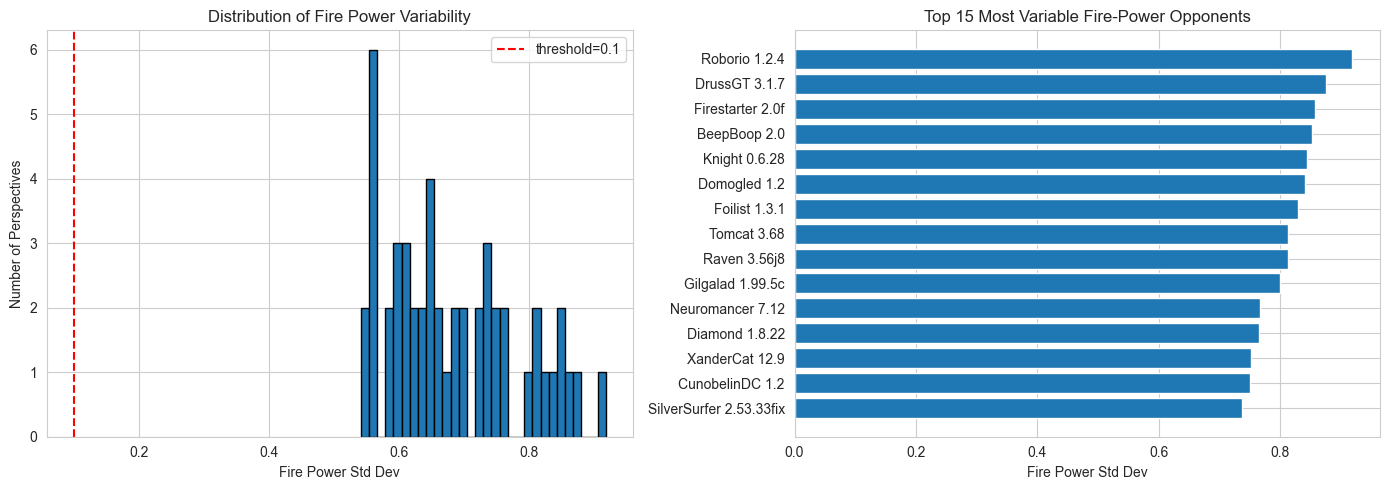

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of power_std
axes[0].hist(power_stats['power_std'].dropna(), bins=30, edgecolor='black')
axes[0].set_xlabel('Fire Power Std Dev')
axes[0].set_ylabel('Number of Perspectives')
axes[0].set_title('Distribution of Fire Power Variability')
axes[0].axvline(0.1, color='red', linestyle='--', label='threshold=0.1')
axes[0].legend()

# Top 15 most variable by std
top = power_stats.dropna().head(15)
axes[1].barh(top['observer'], top['power_std'])
axes[1].set_xlabel('Fire Power Std Dev')
axes[1].set_title('Top 15 Most Variable Fire-Power Opponents')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Consecutive Fire Power Patterns

For bots with variable power: look at consecutive fire pairs within the
same round. Do any bots fire slow then fast (power decreasing → speed
increasing)? That's the wave-stacking signature.

In [4]:
# Sort waves within each (battle_id, round, robot_name) by tick
w = waves.sort_values(['battle_id', 'round', 'robot_name', 'tick']).copy()

# Compute consecutive-fire features within each perspective+round
grp = ['battle_id', 'round', 'robot_name']
w['prev_power'] = w.groupby(grp)['wave_bullet_power'].shift(1)
w['prev_speed'] = w.groupby(grp)['wave_bullet_speed'].shift(1)
w['prev_tick'] = w.groupby(grp)['tick'].shift(1)
w['tick_gap'] = w['tick'] - w['prev_tick']
w['power_delta'] = w['wave_bullet_power'] - w['prev_power']
w['speed_delta'] = w['wave_bullet_speed'] - w['prev_speed']

# Filter to consecutive pairs (both non-null)
pairs = w.dropna(subset=['prev_power']).copy()
print(f"Consecutive fire pairs: {len(pairs):,}")

# Classify: slow-then-fast = prev_speed < current_speed (power dropped)
pairs['slow_then_fast'] = pairs['speed_delta'] > 2.0  # >2 px/tick speed increase
pairs['fast_then_slow'] = pairs['speed_delta'] < -2.0

pattern_counts = pairs.groupby('robot_name').agg(
    total_pairs=('speed_delta', 'count'),
    slow_fast=('slow_then_fast', 'sum'),
    fast_slow=('fast_then_slow', 'sum'),
    mean_tick_gap=('tick_gap', 'mean'),
).reset_index()
pattern_counts['slow_fast_pct'] = (pattern_counts['slow_fast'] / pattern_counts['total_pairs'] * 100).round(1)
pattern_counts = pattern_counts.sort_values('slow_fast_pct', ascending=False)

print("\nBots with highest slow→fast fire pattern (wave-stacking signature):")
print(pattern_counts[pattern_counts['total_pairs'] >= 10].head(20).to_string(index=False))

Consecutive fire pairs: 723,419

Bots with highest slow→fast fire pattern (wave-stacking signature):
           robot_name  total_pairs  slow_fast  fast_slow mean_tick_gap  slow_fast_pct
       Engineer 0.5.4        10915        453        321     14.395602            4.2
CassiusClay 2rho.02no        11468        459        324       14.8842            4.0
        Cardigan 1.09        12108        390        215     14.989263            3.2
        DrussGT 3.1.7        18641        578        384      14.10037            3.1
           Toad 0.14t        11246        333        212     14.854259            3.0
       RougeDC willow        12436        357        257      14.32623            2.9
    deBroglie rev0108         9696        276        100     14.458127            2.8
           Hydra 0.21        11425        304        233      14.45453            2.7
      CunobelinDC 1.2        15024        409        298     13.692026            2.7
       Seraphim 2.3.1        12125     

## 4. Near-Simultaneous Wave Arrivals

For each consecutive fire pair, estimate when both bullets would arrive
at the target. If the difference is ≤ 5 ticks, the opponent faces a
multi-wave dodge problem.

Arrival tick = fire_tick + distance / bullet_speed

In [5]:
# Estimate arrival ticks for each bullet in the pair
pairs = pairs.copy()
pairs['arrival_prev'] = pairs['prev_tick'] + pairs['wave_fire_distance'] / pairs['prev_speed']
pairs['arrival_curr'] = pairs['tick'] + pairs['wave_fire_distance'] / pairs['wave_bullet_speed']
pairs['arrival_gap'] = (pairs['arrival_prev'] - pairs['arrival_curr']).abs()

# Near-simultaneous: arrival gap ≤ 5 ticks
near_simul = pairs[pairs['arrival_gap'] <= 5].copy()
print(f"Near-simultaneous arrivals (≤5 tick gap): {len(near_simul):,} / {len(pairs):,} pairs")
print(f"  = {len(near_simul)/len(pairs)*100:.1f}%")

if len(near_simul) > 0:
    print(f"\nDistance stats for near-simultaneous pairs:")
    print(near_simul['wave_fire_distance'].describe().to_string())

    # Which bots produce the most near-simultaneous arrivals?
    simul_by_bot = (
        near_simul.groupby('robot_name')
        .size()
        .reset_index(name='near_simul_count')
        .sort_values('near_simul_count', ascending=False)
    )
    print(f"\nTop bots producing near-simultaneous wave arrivals:")
    print(simul_by_bot.head(15).to_string(index=False))

Near-simultaneous arrivals (≤5 tick gap): 7,742 / 723,419 pairs
  = 1.1%

Distance stats for near-simultaneous pairs:
count    7742.000000
mean      576.874695
std       124.575287
min        41.931000
25%       492.215508
50%       583.285980
75%       687.769257
max       823.059998

Top bots producing near-simultaneous wave arrivals:
                 robot_name  near_simul_count
               Domogled 1.2              1442
               BeepBoop 2.0              1287
           Neuromancer 7.12              1056
           Firestarter 2.0f               768
             Diamond 1.8.22               636
              Roborio 1.2.4               535
              DrussGT 3.1.7               171
                Tomcat 3.68               169
              Firebird 0.25               147
ScalarR 0.005h.053-noshield               141
    SilverSurfer 2.53.33fix               116
                 Hydra 0.21               101
            CunobelinDC 1.2                87
      CassiusClay

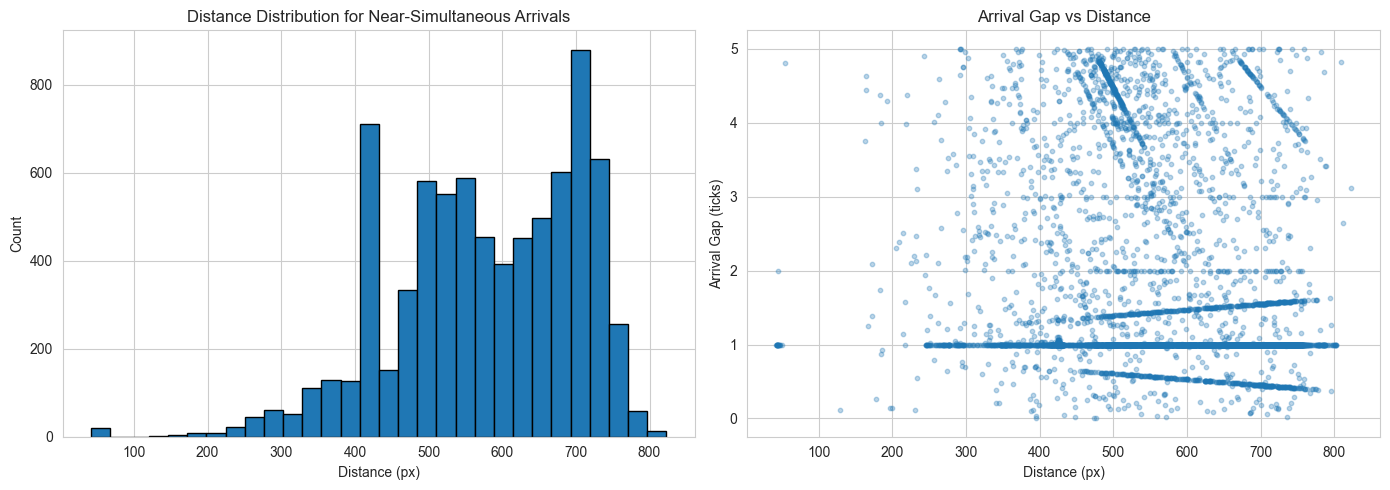

In [7]:
if len(near_simul) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(near_simul['wave_fire_distance'], bins=30, edgecolor='black')
    axes[0].set_xlabel('Distance (px)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distance Distribution for Near-Simultaneous Arrivals')

    axes[1].scatter(near_simul['wave_fire_distance'], near_simul['arrival_gap'],
                    alpha=0.3, s=10)
    axes[1].set_xlabel('Distance (px)')
    axes[1].set_ylabel('Arrival Gap (ticks)')
    axes[1].set_title('Arrival Gap vs Distance')

    plt.tight_layout()
    plt.show()
else:
    print("No near-simultaneous arrivals found.")

## 5. Multi-Wave-in-Flight Frequency

How often are 2+ opponent waves in flight simultaneously? This uses
`ticks.csv` columns: `opponent_wave_distance` and `opponent_wave_remaining`
track the nearest active wave. We can also count by checking how many
waves are "in flight" (fired but not yet arrived) at each tick.

In [8]:
# For each tick in each perspective, count how many waves from waves.csv
# are still in flight (fired before this tick, not yet arrived).
#
# A wave fired at tick t_fire with speed s at distance d arrives at
# t_fire + d/s. It's in flight during [t_fire, t_fire + d/s].

# Build wave intervals per perspective
wi = waves[['battle_id', 'round', 'robot_name', 'tick',
            'wave_bullet_speed', 'wave_fire_distance']].copy()
wi['arrival_tick'] = wi['tick'] + (wi['wave_fire_distance'] / wi['wave_bullet_speed'])
wi = wi.dropna(subset=['arrival_tick'])

# For a sample of perspectives, count waves in flight at each tick
sample_perspectives = (
    wi.groupby(['battle_id', 'round', 'robot_name'])
    .size()
    .reset_index(name='n_waves')
    .query('n_waves >= 10')
    .sample(min(200, len(wi.groupby(['battle_id','round','robot_name']))), random_state=42)
)

multi_wave_fracs = []
for _, row in sample_perspectives.iterrows():
    mask = ((wi['battle_id'] == row['battle_id']) &
            (wi['round'] == row['round']) &
            (wi['robot_name'] == row['robot_name']))
    pv = wi[mask].sort_values('tick')
    if len(pv) < 3:
        continue
    # For each wave's fire tick, count overlapping in-flight waves
    fire_ticks = pv['tick'].values
    arrival_ticks = pv['arrival_tick'].values
    max_concurrent = 0
    concurrent_counts = []
    for i in range(len(fire_ticks)):
        # How many waves are in flight at fire_ticks[i]?
        in_flight = np.sum((fire_ticks <= fire_ticks[i]) & (arrival_ticks > fire_ticks[i]))
        concurrent_counts.append(in_flight)
        max_concurrent = max(max_concurrent, in_flight)
    multi_frac = np.mean(np.array(concurrent_counts) >= 2)
    multi_wave_fracs.append({
        'robot_name': row['robot_name'],
        'max_concurrent': max_concurrent,
        'frac_multi_wave': multi_frac,
    })

mwf = pd.DataFrame(multi_wave_fracs)
print(f"Sampled {len(mwf)} perspectives")
print(f"\nFraction of fire events with 2+ waves in flight:")
print(f"  Mean: {mwf['frac_multi_wave'].mean():.1%}")
print(f"  Median: {mwf['frac_multi_wave'].median():.1%}")
print(f"  Max concurrent waves seen: {mwf['max_concurrent'].max()}")

# Per-bot summary
bot_multi = (
    mwf.groupby('robot_name')
    .agg(mean_multi=('frac_multi_wave', 'mean'),
         max_conc=('max_concurrent', 'max'))
    .sort_values('mean_multi', ascending=False)
    .head(15)
)
print(f"\nTop 15 bots by fraction of multi-wave situations:")
print(bot_multi.to_string())

Sampled 200 perspectives

Fraction of fire events with 2+ waves in flight:
  Mean: 96.3%
  Median: 97.2%
  Max concurrent waves seen: 19

Top 15 bots by fraction of multi-wave situations:
                             mean_multi  max_conc
robot_name                                       
BeepBoop 2.0                   0.989899         4
Raven 3.56j8                   0.981969         3
ScalarR 0.005h.053-noshield    0.980934         3
X2 0.17                        0.980392         4
Roborio 1.2.4                  0.979860         4
Horizon 1.2.2                  0.979377         3
Chalk 2.6.Be                   0.978832         4
Domogled 1.2                   0.978832         4
Phoenix 1.02                   0.978015         3
GresSuffurd 0.4.13             0.977778         4
RougeDC willow                 0.977457         4
Combat 3.25.0                  0.976539         3
Neuromancer 7.12               0.976493         7
Knight 0.6.28                  0.976430         4
Ali 0.4.9   

## 5b. Three-Shot Sequences (Heavy + Medium + Light)

At mid-range (~400–500 px), a 3-bullet pattern creates a 2+1 wave pressure:
heavy+medium converge (exact same arrival), then a light chaser arrives
~8 ticks later — before the opponent finishes dodging the pair.

Exact 3-bullet convergence requires ~740 px (near battlefield diagonal limit),
so we look for the more practical "2+1" staggered pattern instead:
consecutive triplets where the first two bullets arrive within 3 ticks
and the third within 10 ticks of them.

In [6]:
# Build 3-shot consecutive windows within each perspective+round
w3 = waves.sort_values(['battle_id', 'round', 'robot_name', 'tick']).copy()
grp3 = ['battle_id', 'round', 'robot_name']

w3['power_1'] = w3.groupby(grp3)['wave_bullet_power'].shift(2)  # oldest
w3['power_2'] = w3.groupby(grp3)['wave_bullet_power'].shift(1)  # middle
w3['power_3'] = w3['wave_bullet_power']                          # newest

w3['speed_1'] = w3.groupby(grp3)['wave_bullet_speed'].shift(2)
w3['speed_2'] = w3.groupby(grp3)['wave_bullet_speed'].shift(1)
w3['speed_3'] = w3['wave_bullet_speed']

w3['tick_1'] = w3.groupby(grp3)['tick'].shift(2)
w3['tick_2'] = w3.groupby(grp3)['tick'].shift(1)
w3['tick_3'] = w3['tick']

# Filter to valid triplets (all three non-null)
triplets = w3.dropna(subset=['power_1', 'power_2']).copy()

# Estimate arrival ticks (using distance at fire of the 3rd bullet as proxy)
d = triplets['wave_fire_distance']
triplets['arrive_1'] = triplets['tick_1'] + d / triplets['speed_1']
triplets['arrive_2'] = triplets['tick_2'] + d / triplets['speed_2']
triplets['arrive_3'] = triplets['tick_3'] + d / triplets['speed_3']

# Gap between first two arrivals and third
triplets['gap_12'] = (triplets['arrive_1'] - triplets['arrive_2']).abs()
triplets['gap_23'] = (triplets['arrive_2'] - triplets['arrive_3']).abs()
triplets['gap_13'] = (triplets['arrive_1'] - triplets['arrive_3']).abs()
triplets['max_gap'] = triplets[['gap_12', 'gap_23', 'gap_13']].max(axis=1)

# "2+1 pattern": first two converge (gap ≤ 3 ticks), third within 10 ticks
triplets['is_2plus1'] = (triplets['gap_12'] <= 3) & (triplets['max_gap'] <= 10)

# "Full convergence": all three within 5 ticks
triplets['is_triple'] = triplets['max_gap'] <= 5

# Power ordering: heavy → medium → light (slowest first)
triplets['is_decreasing_power'] = (triplets['power_1'] > triplets['power_2']) & \
                                   (triplets['power_2'] > triplets['power_3'])

print(f"Total consecutive triplets: {len(triplets):,}")
print(f"  Decreasing power (heavy→med→light): {triplets['is_decreasing_power'].sum():,}"
      f" ({triplets['is_decreasing_power'].mean()*100:.1f}%)")
print(f"  2+1 pattern (first two converge ≤3t, all ≤10t): {triplets['is_2plus1'].sum():,}"
      f" ({triplets['is_2plus1'].mean()*100:.1f}%)")
print(f"  Full triple convergence (all ≤5t): {triplets['is_triple'].sum():,}"
      f" ({triplets['is_triple'].mean()*100:.1f}%)")

# Which bots produce 2+1 patterns?
if triplets['is_2plus1'].sum() > 0:
    bot_2plus1 = (
        triplets[triplets['is_2plus1']]
        .groupby('robot_name')
        .size()
        .reset_index(name='count_2plus1')
        .sort_values('count_2plus1', ascending=False)
    )
    print(f"\nTop bots producing 2+1 wave patterns:")
    print(bot_2plus1.head(15).to_string(index=False))
    
    print(f"\nDistance stats for 2+1 patterns:")
    print(triplets[triplets['is_2plus1']]['wave_fire_distance'].describe().to_string())

if triplets['is_triple'].sum() > 0:
    print(f"\nDistance stats for full triple convergence:")
    print(triplets[triplets['is_triple']]['wave_fire_distance'].describe().to_string())

Total consecutive triplets: 709,457
  Decreasing power (heavy→med→light): 87,224 (12.3%)
  2+1 pattern (first two converge ≤3t, all ≤10t): 5,724 (0.8%)
  Full triple convergence (all ≤5t): 5,608 (0.8%)

Top bots producing 2+1 wave patterns:
                 robot_name  count_2plus1
               Domogled 1.2          1341
               BeepBoop 2.0          1180
           Neuromancer 7.12           961
           Firestarter 2.0f           683
             Diamond 1.8.22           561
              Roborio 1.2.4           465
              Firebird 0.25           119
                Tomcat 3.68            99
                 Hydra 0.21            87
ScalarR 0.005h.053-noshield            74
    SilverSurfer 2.53.33fix            55
             XanderCat 12.9            34
              Foilist 1.3.1            21
           Gilgalad 1.99.5c            11
              Knight 0.6.28             5

Distance stats for 2+1 patterns:
count    5724.000000
mean      594.450195
std       1

## 6. Do Near-Simultaneous Waves Score Better?

Load `scores.csv` for per-round hit rates. Then correlate: within each
perspective, do rounds with more near-simultaneous opponent wave arrivals
have higher opponent hit rates (i.e., the opponent hits us more)?

We compare:
- Rounds where the opponent produced **near-simultaneous pairs** (≤5 tick gap)
- Rounds where the opponent produced **2+1 triplets**
- Rounds with **no convergence** (all arrivals spaced >5 ticks apart)

In [7]:
# Load scores for per-round hit rates
scores = load_stratified('scores.csv', selection)
print(f"Scores: {len(scores):,} rows")
print("Columns:", list(scores.columns))

d:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
d:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Loaded 400 scores.csv files → 14,000 rows × 17 cols, 50 robots (~2.4 MB)
Scores: 14,000 rows
Columns: ['battle_id', 'round', 'ticks_in_round', 'opponent_name_hash', 'opponent_bot_id_hash', 'opponent_version_hash', 'battlefield_width', 'battlefield_height', 'gun_cooling_rate', 'num_rounds_total', 'damage_dealt', 'damage_received', 'net_damage', 'our_hit_rate', 'opponent_hit_rate', 'win_rate', 'robot_name']


In [8]:
# --- Per-round wave convergence features ---
# For each (battle_id, round, robot_name), count near-simultaneous pairs
# and 2+1 triplets from the earlier analysis.

# 2-bullet near-simultaneous pairs per round
pair_round = (
    near_simul
    .groupby(['battle_id', 'round', 'robot_name'])
    .size()
    .reset_index(name='n_simul_pairs')
)

# 3-bullet 2+1 patterns per round
trip_round = (
    triplets[triplets['is_2plus1']]
    .groupby(['battle_id', 'round', 'robot_name'])
    .size()
    .reset_index(name='n_2plus1_trips')
)

# Total waves per round (for normalization)
total_waves_round = (
    waves.groupby(['battle_id', 'round', 'robot_name'])
    .size()
    .reset_index(name='n_waves_total')
)

# Merge everything onto scores
rnd = scores.merge(total_waves_round, on=['battle_id', 'round', 'robot_name'], how='left')
rnd = rnd.merge(pair_round, on=['battle_id', 'round', 'robot_name'], how='left')
rnd = rnd.merge(trip_round, on=['battle_id', 'round', 'robot_name'], how='left')
rnd['n_simul_pairs'] = rnd['n_simul_pairs'].fillna(0).astype(int)
rnd['n_2plus1_trips'] = rnd['n_2plus1_trips'].fillna(0).astype(int)
rnd['n_waves_total'] = rnd['n_waves_total'].fillna(0).astype(int)

# Categorize rounds
rnd['has_simul_pair'] = rnd['n_simul_pairs'] > 0
rnd['has_2plus1'] = rnd['n_2plus1_trips'] > 0

# Opponent hit rate (how often the opponent hits us — higher = convergence helps attacker)
hit_col = 'opponent_hit_rate'

# Filter to rounds with enough waves to be meaningful
rnd_valid = rnd[rnd['n_waves_total'] >= 5].copy()

print(f"Rounds with ≥5 opponent waves: {len(rnd_valid):,}")
print(f"  With near-simultaneous pairs: {rnd_valid['has_simul_pair'].sum():,}")
print(f"  With 2+1 triplets: {rnd_valid['has_2plus1'].sum():,}")
print(f"  Neither: {(~rnd_valid['has_simul_pair'] & ~rnd_valid['has_2plus1']).sum():,}")

# Compare hit rates
print(f"\n--- Opponent hit rate by convergence category ---\n")

for label, mask in [
    ("No convergence", ~rnd_valid['has_simul_pair'] & ~rnd_valid['has_2plus1']),
    ("Has 2-bullet near-simul pairs", rnd_valid['has_simul_pair']),
    ("Has 3-bullet 2+1 triplets", rnd_valid['has_2plus1']),
    ("Has both", rnd_valid['has_simul_pair'] & rnd_valid['has_2plus1']),
]:
    subset = rnd_valid.loc[mask, hit_col]
    if len(subset) > 0:
        print(f"  {label:40s}: n={len(subset):5d}  "
              f"mean={subset.mean():.4f}  median={subset.median():.4f}  "
              f"std={subset.std():.4f}")

Rounds with ≥5 opponent waves: 13,937
  With near-simultaneous pairs: 1,425
  With 2+1 triplets: 252
  Neither: 12,512

--- Opponent hit rate by convergence category ---

  No convergence                          : n=12512  mean=0.1210  median=0.1163  std=0.0667
  Has 2-bullet near-simul pairs           : n= 1425  mean=0.1127  median=0.1111  std=0.0651
  Has 3-bullet 2+1 triplets               : n=  252  mean=0.0787  median=0.0859  std=0.0735
  Has both                                : n=  252  mean=0.0787  median=0.0859  std=0.0735


In [9]:
# --- Within-bot paired comparison ---
# Control for bot quality: for each OBSERVER (the one being shot at),
# compare rounds where the opponent produced convergence vs not.
# This isolates "does convergence help the shooter?" from "is the shooter
# just a better bot overall?"

print("--- Within-bot paired comparison (same observer, convergence vs not) ---\n")

bot_paired = []
for obs, grp_df in rnd_valid.groupby('robot_name'):
    has = grp_df[grp_df['has_simul_pair']]
    no = grp_df[~grp_df['has_simul_pair']]
    if len(has) >= 3 and len(no) >= 3:
        bot_paired.append({
            'observer': obs,
            'hit_with_convergence': has[hit_col].mean(),
            'hit_without_convergence': no[hit_col].mean(),
            'n_with': len(has),
            'n_without': len(no),
        })

bp = pd.DataFrame(bot_paired)
if len(bp) > 0:
    bp['delta'] = bp['hit_with_convergence'] - bp['hit_without_convergence']
    bp = bp.sort_values('delta', ascending=False)
    
    print(f"Bots with enough data for comparison: {len(bp)}")
    print(f"\nMean opponent {hit_col}:")
    print(f"  Rounds WITH convergence:    {bp['hit_with_convergence'].mean():.4f}")
    print(f"  Rounds WITHOUT convergence: {bp['hit_without_convergence'].mean():.4f}")
    print(f"  Mean delta:                 {bp['delta'].mean():+.4f}")
    print(f"  Bots where convergence helps attacker: {(bp['delta'] > 0).sum()} / {len(bp)}")
    
    # Statistical test
    from scipy.stats import wilcoxon
    stat, p = wilcoxon(bp['hit_with_convergence'], bp['hit_without_convergence'])
    print(f"\n  Wilcoxon signed-rank test: p={p:.4f} "
          f"({'significant' if p < 0.05 else 'NOT significant'} at α=0.05)")
    
    print(f"\nTop 10 observers where convergence HELPS the attacker most:")
    print(bp.head(10)[['observer', 'hit_with_convergence', 'hit_without_convergence', 
                        'delta', 'n_with', 'n_without']].to_string(index=False))
    print(f"\nTop 10 observers where convergence HURTS the attacker:")
    print(bp.tail(10)[['observer', 'hit_with_convergence', 'hit_without_convergence',
                        'delta', 'n_with', 'n_without']].to_string(index=False))
else:
    print("Not enough data for within-bot comparison.")

--- Within-bot paired comparison (same observer, convergence vs not) ---

Bots with enough data for comparison: 50

Mean opponent opponent_hit_rate:
  Rounds WITH convergence:    0.1174
  Rounds WITHOUT convergence: 0.1205
  Mean delta:                 -0.0031
  Bots where convergence helps attacker: 23 / 50

  Wilcoxon signed-rank test: p=0.5985 (NOT significant at α=0.05)

Top 10 observers where convergence HELPS the attacker most:
        observer  hit_with_convergence  hit_without_convergence    delta  n_with  n_without
Gilgalad 1.99.5c              0.148627                 0.121058 0.027568      15        265
  XanderCat 12.9              0.140584                 0.119922 0.020662      25        255
  BlackBox 0.0.2              0.161013                 0.140563 0.020450      15        265
    Domogled 1.2              0.147639                 0.127983 0.019656      44        236
    Raven 3.56j8              0.131352                 0.112212 0.019140      23        257
  Diamond 

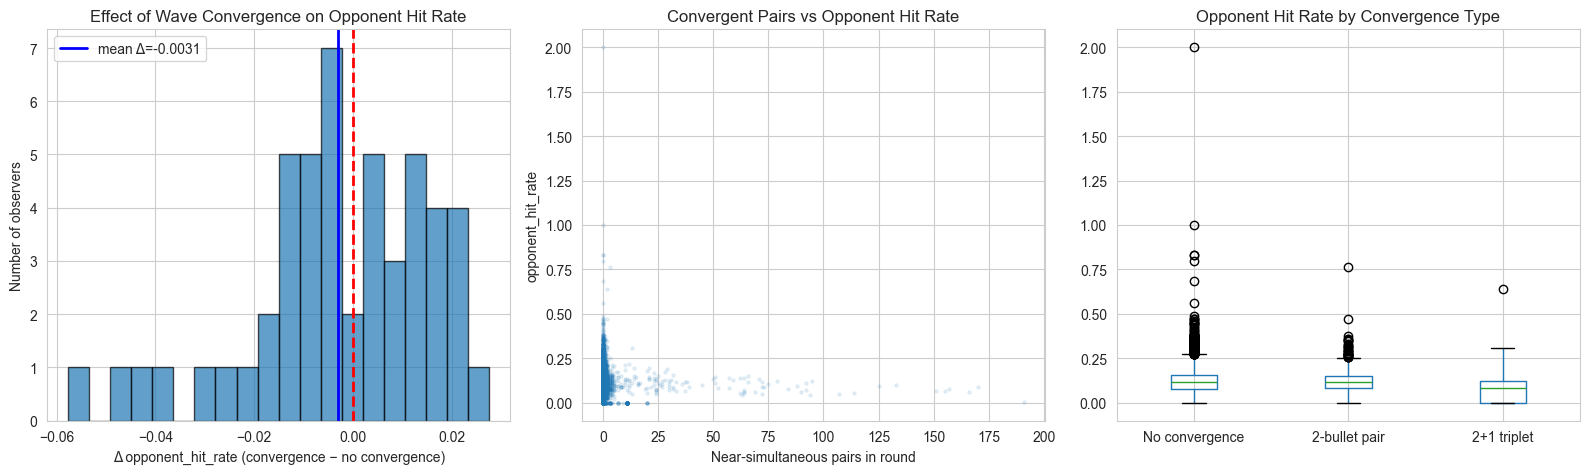

In [10]:
# --- Visualization: convergence vs hit rate ---
if len(bp) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 1. Paired bar chart: with vs without convergence per bot
    axes[0].hist(bp['delta'], bins=20, edgecolor='black', alpha=0.7)
    axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[0].axvline(bp['delta'].mean(), color='blue', linestyle='-', linewidth=2,
                    label=f"mean Δ={bp['delta'].mean():+.4f}")
    axes[0].set_xlabel(f'Δ {hit_col} (convergence − no convergence)')
    axes[0].set_ylabel('Number of observers')
    axes[0].set_title('Effect of Wave Convergence on Opponent Hit Rate')
    axes[0].legend()

    # 2. Scatter: number of convergent pairs vs hit rate
    axes[1].scatter(rnd_valid['n_simul_pairs'], rnd_valid[hit_col], alpha=0.1, s=5)
    axes[1].set_xlabel('Near-simultaneous pairs in round')
    axes[1].set_ylabel(f'{hit_col}')
    axes[1].set_title('Convergent Pairs vs Opponent Hit Rate')

    # 3. Box plot: hit rate by category
    categories = []
    values = []
    for _, row in rnd_valid.iterrows():
        if row['has_2plus1']:
            categories.append('2+1 triplet')
        elif row['has_simul_pair']:
            categories.append('2-bullet pair')
        else:
            categories.append('No convergence')
        values.append(row[hit_col])
    
    cat_df = pd.DataFrame({'category': categories, hit_col: values})
    order = ['No convergence', '2-bullet pair', '2+1 triplet']
    cat_df['category'] = pd.Categorical(cat_df['category'], categories=order, ordered=True)
    cat_df.boxplot(column=hit_col, by='category', ax=axes[2])
    axes[2].set_title('Opponent Hit Rate by Convergence Type')
    axes[2].set_xlabel('')
    plt.suptitle('')  # Remove auto-generated title from boxplot

    plt.tight_layout()
    plt.show()

## 7. Summary

Quick findings (to be verified after execution):

1. **Power variability**: How many bots use variable fire power?
2. **Slow→fast pattern**: Any bots deliberately firing slow then fast?
3. **Near-simultaneous arrivals**: How common at mid-range (275–400 px)?
4. **Multi-wave frequency**: What fraction of combat involves 2+ waves?
5. **3-shot sequences**: Do any bots fire heavy→medium→light triplets?
   - 2+1 pattern (2 converge + chaser): viable at 400–500 px
   - Full triple convergence: requires ~740 px (battlefield diagonal)

Deeper research (deferred):
- Correlate multi-wave situations with hit rate — does the opponent dodge worse?
- Identify which bots are most vulnerable to wave stacking
- Build an `IFirePlan` selector that detects vulnerability and switches
  to wave-stacking mode